In [1]:
!pip install torch sentencepiece records babel tqdm tabulate matplotlib gradio

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Mr.Laptop point\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import sys
sys.path.insert(0, "starter")

from data_prep import AGG_OPS, COND_OPS, MAX_COLS, encode_source, encode_target

assert AGG_OPS == ["", "MAX", "MIN", "COUNT", "SUM", "AVG"], AGG_OPS
assert COND_OPS == ["=", ">", "<"], COND_OPS
assert MAX_COLS == 64

print(
    encode_source(
        "What is Terrence Ross' nationality?",
        ["Player", "No.", "Nationality", "Position", "Years in Toronto", "School/Club Team"]
    )
)

print(
    encode_target(
        {
            "sel": 2,
            "agg": 0,
            "conds": [[0, 0, "Terrence Ross"]]
        }
    )
)

what is terrence ross' nationality? <sep> <c0> player <c1> no. <c2> nationality <c3> position <c4> years in toronto <c5> school/club team
select <c2> where <c0> = terrence ross


In [4]:
import json
from pathlib import Path

DATA_DIR = Path("WikiSQL/data")
AGG_OPS = ["", "MAX", "MIN", "COUNT", "SUM", "AVG"]
COND_OPS = ["=", ">", "<"]
MAX_COLS = 64  # column tokens <c0> ... <c63>


def load_split(split):
    """Return (examples, tables) for 'train', 'dev' or 'test'."""
    tables = {}
    with open(DATA_DIR / f"{split}.tables.jsonl", encoding="utf-8") as f:
        for line in f:
            t = json.loads(line)
            tables[t["id"]] = t
    with open(DATA_DIR / f"{split}.jsonl", encoding="utf-8") as f:
        examples = [json.loads(line) for line in f]
    return examples, tables


def encode_source(question, header):
    """question <sep> <c0> col name <c1> col name ..."""
    cols = " ".join(f"<c{i}> {name}" for i, name in enumerate(header))
    return f"{question.strip()} <sep> {cols}".lower()


def encode_target(sql):
    """{'sel','agg','conds'} -> 'select count <c3> where <c1> = kim manners'"""
    out = ["select"]
    if sql["agg"]:
        out.append(AGG_OPS[sql["agg"]].lower())
    out.append(f"<c{sql['sel']}>")
    for i, (col, op, val) in enumerate(sql["conds"]):
        out += ["where" if i == 0 else "and", f"<c{col}>", COND_OPS[op], str(val)]
    return " ".join(out).lower()


def build_pairs(split):
    examples, tables = load_split(split)
    pairs = []
    for ex in examples:
        header = tables[ex["table_id"]]["header"]
        pairs.append({
            "table_id": ex["table_id"],
            "src": encode_source(ex["question"], header),
            "tgt": encode_target(ex["sql"]),
        })
    return pairs


if __name__ == "__main__":
    for split in ["train", "dev", "test"]:
        pairs = build_pairs(split)
        with open(f"{split}_pairs.jsonl", "w", encoding="utf-8") as f:
            for p in pairs:
                f.write(json.dumps(p, ensure_ascii=False) + "\n")
        print(f"{split}: {len(pairs)} pairs")
    print(pairs[0]["src"])
    print(pairs[0]["tgt"])

train: 56355 pairs
dev: 8421 pairs
test: 15878 pairs
what is terrence ross' nationality <sep> <c0> player <c1> no. <c2> nationality <c3> position <c4> years in toronto <c5> school/club team
select <c2> where <c0> = terrence ross


In [5]:
import json
import sentencepiece as spm
from data_prep import MAX_COLS

PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3
SPECIAL = ["<sep>"] + [f"<c{i}>" for i in range(MAX_COLS)]


def read_pairs(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f]


def train_tokenizer(train_path="train_pairs.jsonl", vocab_size=8000):
    pairs = read_pairs(train_path)
    with open("spm_corpus.txt", "w", encoding="utf-8") as f:
        for p in pairs:  # ONE shared vocabulary for
            f.write(p["src"] + "\n")  # source and target, as in
            f.write(p["tgt"] + "\n")  # the original Transformer
    spm.SentencePieceTrainer.train(
        input="spm_corpus.txt", model_prefix="sql_sp",
        vocab_size=vocab_size, model_type="bpe",
        character_coverage=1.0,
        user_defined_symbols=SPECIAL,  # never split <sep>, <c0>, ...
        pad_id=PAD_ID, unk_id=UNK_ID, bos_id=BOS_ID, eos_id=EOS_ID,
    )
    return spm.SentencePieceProcessor(model_file="sql_sp.model")


if __name__ == "__main__":
    sp = train_tokenizer()
    p = read_pairs("dev_pairs.jsonl")[0]
    print(sp.encode(p["src"], out_type=str))
    print(sp.encode(p["tgt"], out_type=str))
    print(sp.decode(sp.encode(p["tgt"])) == p["tgt"])

['▁what', '▁position', '▁does', '▁the', '▁player', '▁who', '▁played', '▁for', '▁but', 'ler', '▁cc', '▁(', 'ks', ')', '▁play', '?', '▁', '<sep>', '▁', '<c0>', '▁player', '▁', '<c1>', '▁no', '.', '▁', '<c2>', '▁nationality', '▁', '<c3>', '▁position', '▁', '<c4>', '▁years', '▁in', '▁toronto', '▁', '<c5>', '▁school', '/', 'club', '▁team']
['▁select', '▁', '<c3>', '▁where', '▁', '<c5>', '▁=', '▁but', 'ler', '▁cc', '▁(', 'ks', ')']
True


In [ ]:
import sentencepiece as spm
from dataset import make_loader
from embeddings import TokenEmbedding, InputLayer
from tokenizer import PAD_ID

sp = spm.SentencePieceProcessor(model_file="sql_sp.model")
train_dl = make_loader("train_pairs.jsonl", sp, train=True)
dev_dl = make_loader("dev_pairs.jsonl", sp, train=False)
src, tgt = next(iter(train_dl))
print("src", tuple(src.shape), "tgt", tuple(tgt.shape))
d_model = 256
shared = TokenEmbedding(sp.get_piece_size(), d_model, PAD_ID)
enc_in = InputLayer(shared, d_model)  
dec_in = InputLayer(shared, d_model) 
x = enc_in(src)  
y = dec_in(tgt[:, :-1])  
print("encoder input", tuple(x.shape), "decoder input", tuple(y.shape))

train_pairs.jsonl: kept 56336, skipped 19
dev_pairs.jsonl: kept 8421, skipped 0
src (64, 72) tgt (64, 30)
encoder input (64, 72, 256) decoder input (64, 29, 256)


In [7]:
import sys, statistics
sys.path.insert(0, "starter")
import sentencepiece as spm
from dataset import SQLDataset

sp = spm.SentencePieceProcessor(model_file="sql_sp.model")
for split, train in [("train", True), ("dev", False), ("test", False)]:
    ds = SQLDataset(f"{split}_pairs.jsonl", sp, train=train)  # prints kept/skipped
    sl = [len(s) for s, _ in ds.items]     # source lengths (includes </s>)
    tl = [len(t) for _, t in ds.items]     # target lengths (includes <s> and </s>)
    print(split, "pairs", len(ds),
          "| src mean/max", round(statistics.mean(sl), 1), max(sl),
          "| tgt mean/max", round(statistics.mean(tl), 1), max(tl))

train_pairs.jsonl: kept 56336, skipped 19
train pairs 56336 | src mean/max 42.5 160 | tgt mean/max 14.8 64
dev_pairs.jsonl: kept 8421, skipped 0
dev pairs 8421 | src mean/max 42.5 167 | tgt mean/max 14.8 44
test_pairs.jsonl: kept 15878, skipped 0
test pairs 15878 | src mean/max 42.7 260 | tgt mean/max 14.9 46


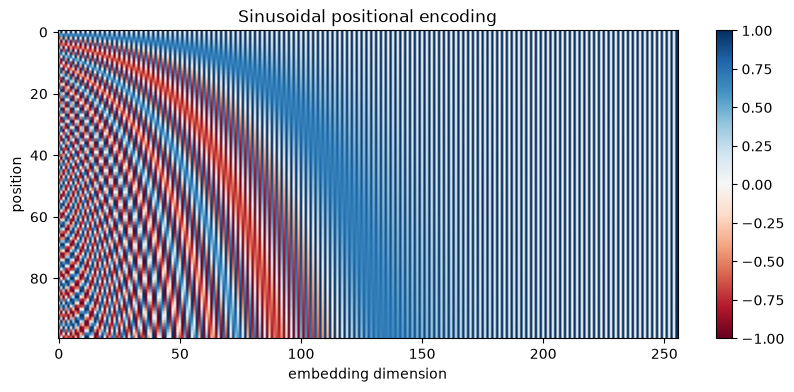

In [ ]:
import sys; sys.path.insert(0, "starter")
import matplotlib.pyplot as plt
from embeddings import PositionalEncoding
pe = PositionalEncoding(256).pe[0, :100, :256]    
plt.figure(figsize=(10, 4))
plt.imshow(pe.numpy(), aspect="auto", cmap="RdBu")  
plt.xlabel("embedding dimension"); plt.ylabel("position"); plt.colorbar()
plt.title("Sinusoidal positional encoding")
plt.savefig("results/fig1_positional_encoding.png", dpi=150, bbox_inches="tight")

In [9]:
import json, os
import numpy as np
import sentencepiece as spm
from tokenizer import read_pairs

os.makedirs("results", exist_ok=True)
sp = spm.SentencePieceProcessor(model_file="starter/sql_sp.model")

MAX_SRC, MAX_TGT = 160, 64          # same limits the starter's SQLDataset uses
stats = {}
for split in ["train", "dev", "test"]:
    pairs = read_pairs(f"starter/{split}_pairs.jsonl")
    src_len = [len(sp.encode(p["src"])) + 1 for p in pairs]    # +1 for </s>
    tgt_len = [len(sp.encode(p["tgt"])) + 2 for p in pairs]    # +2 for <s> and </s>
    too_long = sum(1 for s, t in zip(src_len, tgt_len) if s > MAX_SRC or t > MAX_TGT)
    stats[split] = {
        "pairs": len(pairs),
        "src_mean": float(np.mean(src_len)), "src_max": int(np.max(src_len)),
        "tgt_mean": float(np.mean(tgt_len)), "tgt_max": int(np.max(tgt_len)),
        # only the training set drops long pairs; dev/test keep every row
        "dropped": too_long if split == "train" else "–",
    }

def cell(split, key, fmt="{}"):
    return fmt.format(stats[split][key])

table1 = f"""| | Train | Dev | Test |
|---|---|---|---|
| Pairs | {cell('train','pairs')} | {cell('dev','pairs')} | {cell('test','pairs')} |
| Mean / max source length (tokens) | {stats['train']['src_mean']:.1f} / {stats['train']['src_max']} | {stats['dev']['src_mean']:.1f} / {stats['dev']['src_max']} | {stats['test']['src_mean']:.1f} / {stats['test']['src_max']} |
| Mean / max target length (tokens) | {stats['train']['tgt_mean']:.1f} / {stats['train']['tgt_max']} | {stats['dev']['tgt_mean']:.1f} / {stats['dev']['tgt_max']} | {stats['test']['tgt_mean']:.1f} / {stats['test']['tgt_max']} |
| Pairs dropped as too long | {stats['train']['dropped']} | – | – |
"""
print(table1)
open("results/table1_data.md", "w").write(table1)
json.dump(stats, open("results/table1_data.json", "w"), indent=2)

| | Train | Dev | Test |
|---|---|---|---|
| Pairs | 56355 | 8421 | 15878 |
| Mean / max source length (tokens) | 42.5 / 222 | 42.5 / 167 | 42.7 / 260 |
| Mean / max target length (tokens) | 14.8 / 65 | 14.8 / 44 | 14.9 / 46 |
| Pairs dropped as too long | 19 | – | – |



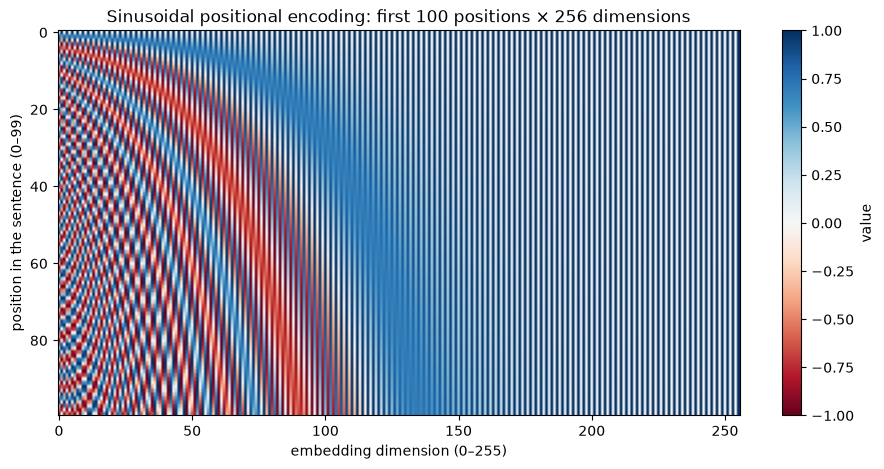

(100, 256)


In [10]:
import matplotlib.pyplot as plt
from embeddings import PositionalEncoding

pe = PositionalEncoding(d_model=256, max_len=512).pe[0, :100, :].numpy()   # (100 positions, 256 dims)

plt.figure(figsize=(11, 5))
plt.imshow(pe, aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
plt.colorbar(label="value")
plt.xlabel("embedding dimension (0–255)")
plt.ylabel("position in the sentence (0–99)")
plt.title("Sinusoidal positional encoding: first 100 positions × 256 dimensions")
plt.savefig("results/fig1_positional_encoding.png", dpi=150, bbox_inches="tight")
plt.show()
print(pe.shape)

In [34]:
import math
import torch
import torch.nn as nn
def scaled_dot_product_attention(q, k, v, mask=None):
    d_k = q.size(-1)
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(~mask, -1e9)
    weights = torch.softmax(scores, dim=-1)
    output = torch.matmul(weights, v)
    return output, weights
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=256, h=4):
        super().__init__()
        assert d_model % h == 0, "d_model must be divisible by the number of heads"
        self.h = h
        self.d_k = d_model // h
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)
    def _split_heads(self, x):
        batch, length, _ = x.shape
        x = x.view(batch, length, self.h, self.d_k)
        return x.transpose(1, 2)
    def forward(self, query, key, value, mask=None):
        batch = query.size(0)
        q = self._split_heads(self.w_q(query))
        k = self._split_heads(self.w_k(key))
        v = self._split_heads(self.w_v(value))
        out, weights = scaled_dot_product_attention(q, k, v, mask)
        out = out.transpose(1, 2).contiguous().view(batch, -1, self.h * self.d_k)
        return self.w_o(out), weights

In [38]:
import torch.nn as nn
from model.attention import MultiHeadAttention
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model=256, d_ff=1024):
        super().__init__()
        self.w1 = nn.Linear(d_model, d_ff)
        self.w2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.w2(self.relu(self.w1(x)))
class EncoderLayer(nn.Module):
    def __init__(self, d_model=256, h=4, d_ff=1024, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, h)
        self.ffn = PositionwiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
    def forward(self, x, src_mask):
        attn_out, _ = self.self_attn(x, x, x, src_mask)
        x = self.norm1(x + self.drop(attn_out))
        x = self.norm2(x + self.drop(self.ffn(x)))
        return x
class DecoderLayer(nn.Module):
    def __init__(self, d_model=256, h=4, d_ff=1024, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, h)
        self.cross_attn = MultiHeadAttention(d_model, h)
        self.ffn = PositionwiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
        self.cross_attn_weights = None
    def forward(self, x, memory, tgt_mask, src_mask):
        attn_out, _ = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.drop(attn_out))
        cross_out, cross_w = self.cross_attn(x, memory, memory, src_mask)
        self.cross_attn_weights = cross_w.detach()
        x = self.norm2(x + self.drop(cross_out))
        x = self.norm3(x + self.drop(self.ffn(x)))
        return x
class Encoder(nn.Module):
    def __init__(self, n_layers=3, d_model=256, h=4, d_ff=1024, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, h, d_ff, dropout) for _ in range(n_layers)]
        )
    def forward(self, x, src_mask):
        for layer in self.layers:
            x = layer(x, src_mask)
        return x
class Decoder(nn.Module):
    def __init__(self, n_layers=3, d_model=256, h=4, d_ff=1024, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, h, d_ff, dropout) for _ in range(n_layers)]
        )
    def forward(self, x, memory, tgt_mask, src_mask):
        for layer in self.layers:
            x = layer(x, memory, tgt_mask, src_mask)
        return x

In [36]:
import torch.nn as nn
from model.attention import MultiHeadAttention
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model=256, d_ff=1024):
        super().__init__()
        self.w1 = nn.Linear(d_model, d_ff)
        self.w2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.w2(self.relu(self.w1(x)))
class EncoderLayer(nn.Module):
    def __init__(self, d_model=256, h=4, d_ff=1024, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, h)
        self.ffn = PositionwiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
    def forward(self, x, src_mask):
        attn_out, _ = self.self_attn(x, x, x, src_mask)
        x = self.norm1(x + self.drop(attn_out))
        x = self.norm2(x + self.drop(self.ffn(x)))
        return x
class DecoderLayer(nn.Module):
    def __init__(self, d_model=256, h=4, d_ff=1024, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, h)
        self.cross_attn = MultiHeadAttention(d_model, h)
        self.ffn = PositionwiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
        self.cross_attn_weights = None
    def forward(self, x, memory, tgt_mask, src_mask):
        attn_out, _ = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.drop(attn_out))
        cross_out, cross_w = self.cross_attn(x, memory, memory, src_mask)
        self.cross_attn_weights = cross_w.detach()
        x = self.norm2(x + self.drop(cross_out))
        x = self.norm3(x + self.drop(self.ffn(x)))
        return x
class Encoder(nn.Module):
    def __init__(self, n_layers=3, d_model=256, h=4, d_ff=1024, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, h, d_ff, dropout) for _ in range(n_layers)]
        )
    def forward(self, x, src_mask):
        for layer in self.layers:
            x = layer(x, src_mask)
        return x
class Decoder(nn.Module):
    def __init__(self, n_layers=3, d_model=256, h=4, d_ff=1024, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, h, d_ff, dropout) for _ in range(n_layers)]
        )
    def forward(self, x, memory, tgt_mask, src_mask):
        for layer in self.layers:
            x = layer(x, memory, tgt_mask, src_mask)
        return x

In [ ]:
import sys
from pathlib import Path
import torch
import torch.nn as nn
sys.path.insert(0, str(Path(__file__).resolve().parent.parent/ "starter"))
from embeddings import TokenEmbedding, InputLayer
from model.layers import Encoder, Decoder

def make_pad_mask(ids, pad_id=0):
    return (ids != pad_id).unsqueeze(1).unsqueeze(2)

def make_causal_mask(length, device=None):
    return torch.tril(torch.ones(length, length, dtype=torch.bool, device=device)).unsqueeze(0).unsqueeze(0)

def make_tgt_mask(tgt_ids, pad_id=0):
    pad = make_pad_mask(tgt_ids, pad_id)
    causal = make_causal_mask(tgt_ids.size(1), tgt_ids.device)
    return pad & causal

class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model=256, h=4, n_layers=3, d_ff=1024,
                 dropout=0.1, pad_id=0):
        super().__init__()
        self.pad_id = pad_id
        shared = TokenEmbedding(vocab_size, d_model, pad_id)
        self.src_in = InputLayer(shared, d_model, dropout=dropout)
        self.tgt_in = InputLayer(shared, d_model, dropout=dropout)
        self.encoder = Encoder(n_layers, d_model, h, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, h, d_ff, dropout)
        self.out_proj = nn.Linear(d_model, vocab_size, bias=False)
        self.out_proj.weight = shared.emb.weight
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
        with torch.no_grad():
            self.src_in.tok.emb.weight[self.pad_id].zero_()

    def encode(self, src):
        src_mask = make_pad_mask(src, self.pad_id)
        memory = self.encoder(self.src_in(src), src_mask)
        return memory, src_mask
    
    def decode(self, tgt_in, memory, src_mask):
        tgt_mask = make_tgt_mask(tgt_in, self.pad_id)
        hidden = self.decoder(self.tgt_in(tgt_in), memory, tgt_mask, src_mask)
        return self.out_proj(hidden)

    
    def forward(self, src, tgt_in):
        memory, src_mask = self.encode(src)
        return self.decode(tgt_in, memory, src_mask)
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
import importlib, sys
import sentencepiece as spm
import torch
sys.path.insert(0, "starter")
import model.attention, model.layers, model.transformer

for m in (model.attention, model.layers, model.transformer):
    importlib.reload(m)

from model.transformer import Transformer, count_parameters

sp = spm.SentencePieceProcessor(model_file="starter/sql_sp.model")
V = sp.get_piece_size()
net = Transformer(vocab_size=V)
n_params = count_parameters(net)
print("vocab size          :", V)
print("trainable parameters:", f"{n_params:,}")

In [ ]:
import torch
from model.attention import scaled_dot_product_attention
torch.manual_seed(0)
net.eval()

src = torch.randint(4, V, (2, 10))
tgt = torch.randint(4, V, (2, 8))


normal_output = net(src, tgt)

changed_tgt = tgt.clone()
changed_tgt[:, -1] = (tgt[:, -1] - 4 + 1) % (V - 4) + 4

changed_output = net(src, changed_tgt)

earlier_same = torch.allclose(
    normal_output[:, :-1],
    changed_output[:, :-1],
    atol=1e-5
)

last_changed = not torch.allclose(
    normal_output[:, -1],
    changed_output[:, -1],
    atol=1e-5
)

print(
    f"[1] Causal mask: earlier outputs unchanged = {earlier_same} | "
    f"last output changed = {last_changed}"
)

src_padded = torch.cat(
    [src, torch.zeros(2, 6, dtype=torch.long)],
    dim=1
)
padded_output = net(src_padded, tgt)
padding_works = torch.allclose(
    normal_output,
    padded_output,
    atol=1e-5
)
print(
    f"[2] Padding mask: output unchanged after adding <pad> "
    f"= {padding_works}"
)

q = torch.randn(2, 4, 5, 64)
k = torch.randn(2, 4, 7, 64)
v = torch.randn(2, 4, 7, 64)
mask = torch.zeros(2, 1, 1, 7, dtype=torch.bool)
mask[0, :, :, :7] = True
mask[1, :, :, :4] = True

_, attention_weights = scaled_dot_product_attention(
    q, k, v, mask
)
rows_sum_to_one = torch.allclose(
    attention_weights.sum(-1),
    torch.ones_like(attention_weights.sum(-1)),
    atol=1e-5
)
masked_zero = (
    attention_weights
    .masked_select(~mask.expand_as(attention_weights))
    .abs()
    .max()
    .item() < 1e-6
)
print(
    f"[3] Attention rows: every row sums to 1 = {rows_sum_to_one} | "
    f"masked positions get weight 0 = {masked_zero}"
)

net(src_padded, tgt)
cross_weights = net.decoder.layers[-1].cross_attn_weights
cross_rows_sum_to_one = torch.allclose(
    cross_weights.sum(-1),
    torch.ones_like(cross_weights.sum(-1)),
    atol=1e-5
)
padded_source_weight = cross_weights[..., 10:].abs().max().item()
print(
    f"    Real model: cross-attention rows sum to 1 = "
    f"{cross_rows_sum_to_one} | "
    f"weight on padded source positions = "
    f"{padded_source_weight:.1e}"
)

shared = (
    net.out_proj.weight is net.src_in.tok.emb.weight
    and
    net.out_proj.weight is net.tgt_in.tok.emb.weight
)
print(
    f"[4] Weight sharing: output projection and embedding are "
    f"the same tensor = {shared}"
)

In [ ]:
import argparse
import json
import sys
import time
from pathlib import Path
import torch.nn as nn


ROOT = Path(__file__).resolve().parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "starter"))

from dataset import make_loader
from tokenizer import PAD_ID
from model.transformer import Transformer, count_parameters


CONFIG = {
    "d_model": 256,
    "h": 4,
    "n_layers": 3,
    "d_ff": 1024,
    "dropout": 0.1
}

WARMUP = 4000
LABEL_SMOOTHING = 0.1


def noam_lr(step):
    step = max(step, 1)
    return CONFIG["d_model"] ** -0.5 * min(
        step ** -0.5,
        step * WARMUP ** -1.5
    )


def run_epoch(model, loader, criterion, device, optimizer=None, scheduler=None):
    training = optimizer is not None
    model.train(training)

    total_loss = 0
    total_tokens = 0

    for src, tgt in loader:
        src = src.to(device)
        tgt = tgt.to(device)

        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        with torch.set_grad_enabled(training):
            logits = model(src, tgt_input)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                tgt_output.reshape(-1)
            )

        if training:
            optimizer.zero_grad(),loss.backward(),optimizer.step(),scheduler.step()

        tokens = (tgt_output != PAD_ID).sum().item()

        total_loss += loss.item() * tokens
        total_tokens += tokens
    return total_loss / total_tokens


def main():

    parser = argparse.ArgumentParser()

    parser.add_argument("--epochs", type=int, default=20)
    parser.add_argument("--batch_size", type=int, default=64)
    parser.add_argument("--ckpt_dir", default="checkpoints")
    parser.add_argument("--results_dir", default="results")
    parser.add_argument("--resume", action="store_true")

    args = parser.parse_args()

    torch.manual_seed(42)

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    ckpt_dir = Path(args.ckpt_dir)
    results_dir = Path(args.results_dir)

    ckpt_dir.mkdir(exist_ok=True)
    results_dir.mkdir(exist_ok=True)

    sp = spm.SentencePieceProcessor(
        model_file=str(ROOT / "starter" / "sql_sp.model")
    )

    vocab_size = sp.get_piece_size()

    train_loader = make_loader(
        str(ROOT / "starter" / "train_pairs.jsonl"),sp,train=True,batch_size=args.batch_size)

    dev_loader = make_loader(str(ROOT / "starter" / "dev_pairs.jsonl"),sp,train=False,batch_size=args.batch_size)

    model = Transformer(vocab_size,**CONFIG).to(device)

    print( f"Device: {device}" f"\nTrainable parameters: {count_parameters(model):,}")

    criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID,label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.Adam( model.parameters(),lr=1.0,betas=(0.9, 0.98),eps=1e-9 )
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer,lr_lambda=lambda step: noam_lr(step + 1))

    history = []
    best_dev_loss = float("inf")
    best_epoch = 0
    start_epoch = 1

    last_checkpoint = ckpt_dir / "last.pt"

    if args.resume and last_checkpoint.exists():

        checkpoint = torch.load( last_checkpoint, map_location=device)

        model.load_state_dict(checkpoint["model"])
        optimizer.load_state_dict(checkpoint["optimizer"])
        scheduler.load_state_dict(checkpoint["scheduler"])

        history = checkpoint["history"]
        best_dev_loss = checkpoint["best_dev"]
        best_epoch = checkpoint["best_epoch"]
        start_epoch = checkpoint["epoch"] + 1

        print(f"Resumed from epoch {checkpoint['epoch']}")

    start_time = time.time()

    for epoch in range(start_epoch, args.epochs + 1):
        train_loss = run_epoch(model,train_loader,criterion,device,optimizer,scheduler)
        dev_loss = run_epoch(model,dev_loader,criterion,device)
        learning_rate = optimizer.param_groups[0]["lr"]

        history.append({ "epoch": epoch,"train_loss": train_loss,"dev_loss": dev_loss,"lr": learning_rate})

        if dev_loss < best_dev_loss:
            best_dev_loss = dev_loss
            best_epoch = epoch
            torch.save({"model": model.state_dict(),"config": CONFIG,"vocab_size": vocab_size,"epoch": epoch,"dev_loss": dev_loss},
                ckpt_dir / "best.pt"
            )
            best = " <- best"
        else:
            best = ""
        torch.save({"model": model.state_dict(),"optimizer": optimizer.state_dict(),"scheduler": scheduler.state_dict(),
                "history": history,"best_dev": best_dev_loss, "best_epoch": best_epoch, "epoch": epoch},last_checkpoint)

        (results_dir / "history.json").write_text(
            json.dumps(history, indent=2)
        )
        print( f"Epoch {epoch:2d}/{args.epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Dev loss: {dev_loss:.4f} | "
            f"LR: {learning_rate:.6f}{best}"
        )

    training_time = (time.time() - start_time) / 60
    training_info = {
        "epochs_trained": len(history),
        "best_epoch": best_epoch,
        "best_dev_loss": best_dev_loss,
        "training_time_min": training_time,
        "trainable_parameters": count_parameters(model),
        "device": torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else "CPU"
    }

    (results_dir / "training_info.json").write_text(
        json.dumps(training_info, indent=2)
    )

    print("\nTraining complete.")
    print(training_info)
if __name__ == "__main__":
    main()